<a href="https://colab.research.google.com/github/jeonxvix/dengue/blob/analisis-dengue/dengue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

In [ ]:
df = pd.read_csv("/content/datos_abiertos_vigilancia_dengue_2000_2024.csv", sep=";")

df.head()

/tmp/ipykernel_5082/2050728011.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/datos_abiertos_vigilancia_dengue_2000_2024.csv", sep=";")


,departamento,provincia,distrito,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,LORETO,ALTO AMAZONAS,YURIMAGUAS,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160201,NaN,58,A,M
1,LORETO,ALTO AMAZONAS,YURIMAGUAS,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160201,NaN,44,A,F
2,LORETO,ALTO AMAZONAS,YURIMAGUAS,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160201,NaN,21,A,F
3,LORETO,MAYNAS,IQUITOS,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160101,NaN,74,A,M
4,LORETO,MAYNAS,IQUITOS,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160101,NaN,42,A,F


In [ ]:
def limpiar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).strip().upper()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

columnas_texto = ["departamento", "provincia", "distrito", "enfermedad", "tipo_edad", "sexo"]

for col in columnas_texto:
    df[col] = df[col].apply(limpiar_texto)

In [ ]:
df["enfermedad"].value_counts()

,count
enfermedad,
DENGUE SIN SIGNOS DE ALARMA,915243
DENGUE CON SIGNOS DE ALARMA,110166
DENGUE GRAVE,4012


In [ ]:
df["riesgo_alarma"] = np.where(
    df["enfermedad"].str.contains("CON SIGNOS", na=False),
    1,
    0
)

df[["enfermedad", "riesgo_alarma"]].head()

,enfermedad,riesgo_alarma
0,DENGUE SIN SIGNOS DE ALARMA,0
1,DENGUE SIN SIGNOS DE ALARMA,0
2,DENGUE SIN SIGNOS DE ALARMA,0
3,DENGUE SIN SIGNOS DE ALARMA,0
4,DENGUE SIN SIGNOS DE ALARMA,0


In [ ]:
df["riesgo_alarma"].value_counts()

,count
riesgo_alarma,
0,919255
1,110166


In [ ]:
df["riesgo_alarma"].value_counts(normalize=True) * 100

,proportion
riesgo_alarma,
0,89.298256
1,10.701744


In [ ]:
def convertir_edad_anios(row):
    edad = row["edad"]
    tipo = row["tipo_edad"]

    if pd.isna(edad):
        return np.nan

    if tipo == "A":   # años
        return edad
    elif tipo == "M": # meses
        return edad / 12
    elif tipo == "D": # días
        return edad / 365
    else:
        return edad

df["edad_anios"] = df.apply(convertir_edad_anios, axis=1)

In [ ]:
bins = [0, 5, 12, 18, 30, 45, 60, 120]
labels = ["0-5", "6-12", "13-18", "19-30", "31-45", "46-60", "60+"]

df["grupo_edad"] = pd.cut(df["edad_anios"], bins=bins, labels=labels, include_lowest=True)

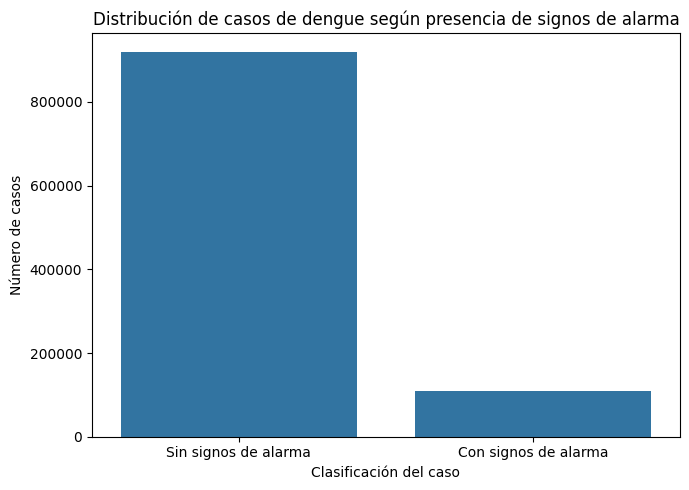

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="riesgo_alarma")
plt.xticks([0,1], ["Sin signos de alarma", "Con signos de alarma"])
plt.title("Distribución de casos de dengue según presencia de signos de alarma")
plt.xlabel("Clasificación del caso")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.savefig("figura_1_distribucion_clases.png", dpi=300)
plt.show()

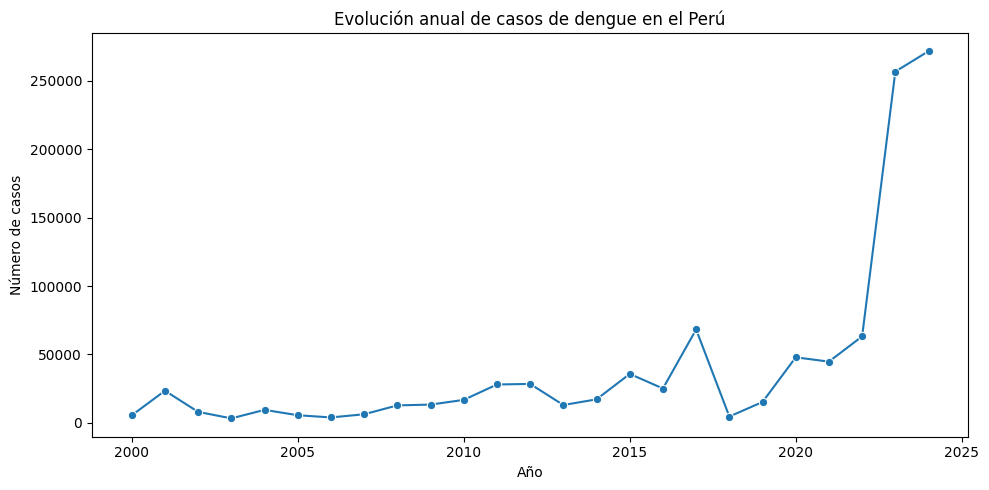

In [ ]:
casos_anio = df.groupby("ano").size().reset_index(name="casos")

plt.figure(figsize=(10,5))
sns.lineplot(data=casos_anio, x="ano", y="casos", marker="o")
plt.title("Evolución anual de casos de dengue en el Perú")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.savefig("figura_2_casos_por_anio.png", dpi=300)
plt.show()

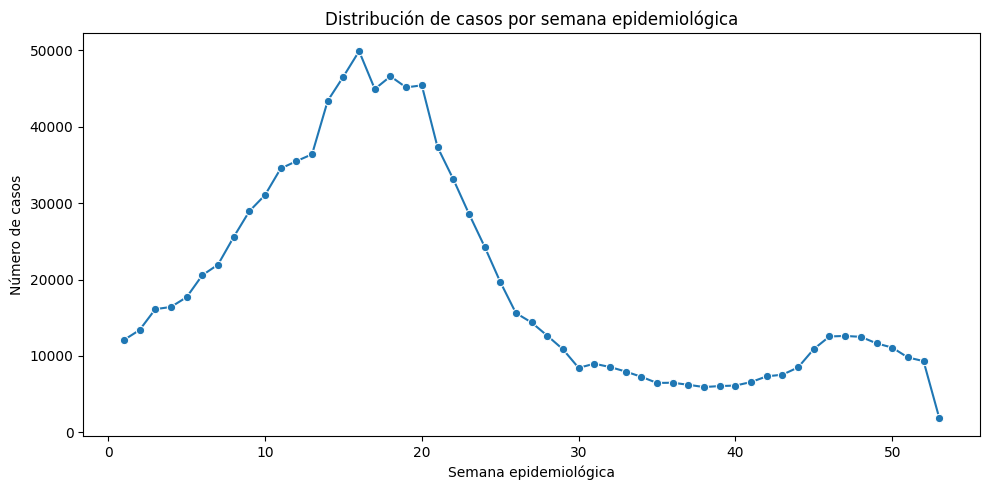

In [ ]:
casos_semana = df.groupby("semana").size().reset_index(name="casos")

plt.figure(figsize=(10,5))
sns.lineplot(data=casos_semana, x="semana", y="casos", marker="o")
plt.title("Distribución de casos por semana epidemiológica")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.savefig("figura_3_casos_por_semana.png", dpi=300)
plt.show()

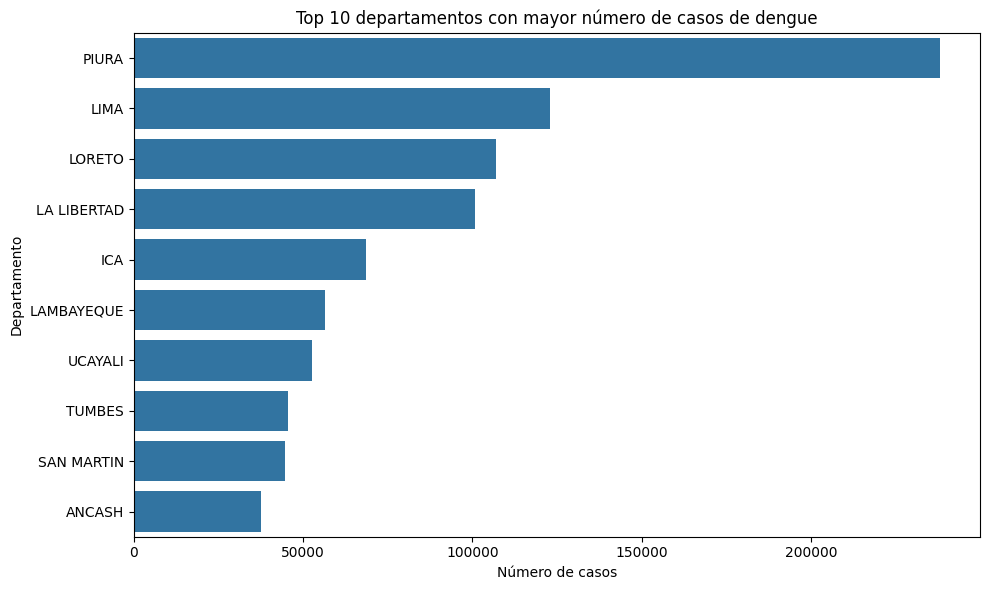

In [ ]:
top_departamentos = df["departamento"].value_counts().head(10).reset_index()
top_departamentos.columns = ["departamento", "casos"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_departamentos, y="departamento", x="casos")
plt.title("Top 10 departamentos con mayor número de casos de dengue")
plt.xlabel("Número de casos")
plt.ylabel("Departamento")
plt.tight_layout()
plt.savefig("figura_4_top_departamentos.png", dpi=300)
plt.show()

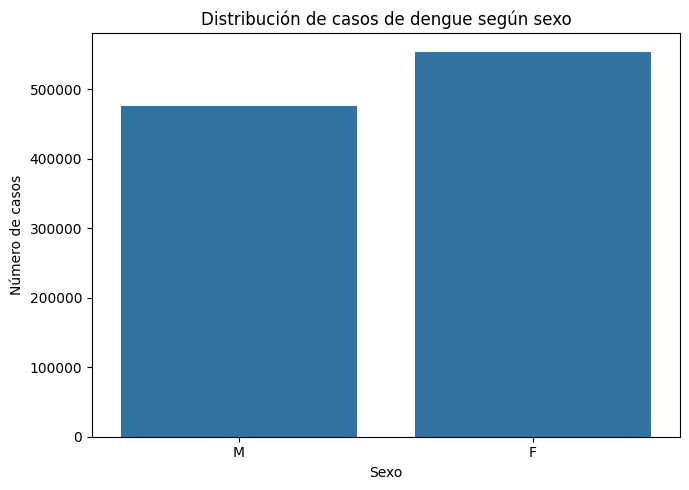

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="sexo")
plt.title("Distribución de casos de dengue según sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.savefig("figura_5_casos_por_sexo.png", dpi=300)
plt.show()

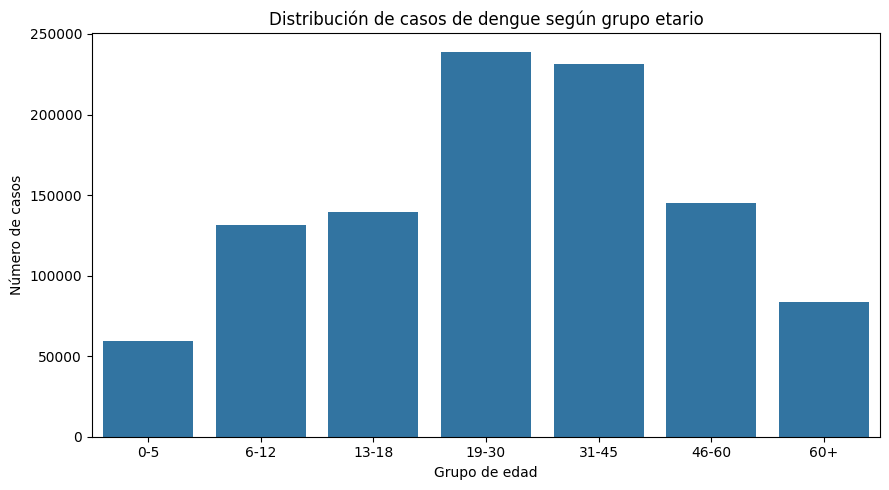

In [ ]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="grupo_edad", order=labels)
plt.title("Distribución de casos de dengue según grupo etario")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.savefig("figura_6_grupo_edad.png", dpi=300)
plt.show()

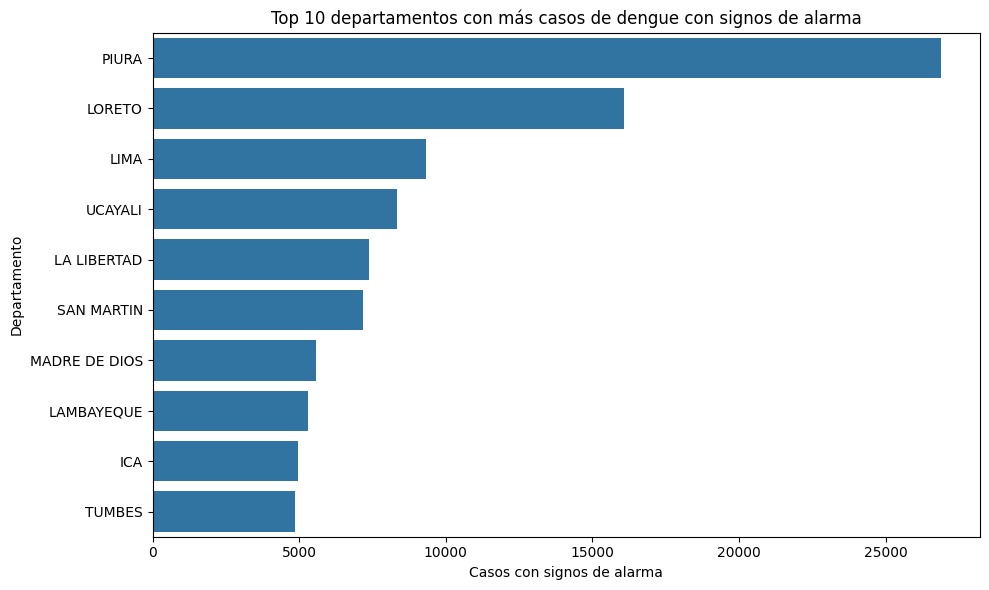

In [ ]:
alarma_departamento = df[df["riesgo_alarma"] == 1]["departamento"].value_counts().head(10).reset_index()
alarma_departamento.columns = ["departamento", "casos_con_alarma"]

plt.figure(figsize=(10,6))
sns.barplot(data=alarma_departamento, y="departamento", x="casos_con_alarma")
plt.title("Top 10 departamentos con más casos de dengue con signos de alarma")
plt.xlabel("Casos con signos de alarma")
plt.ylabel("Departamento")
plt.tight_layout()
plt.savefig("figura_7_alarma_departamento.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# 6. PREPARACIÓN DE DATOS PARA MACHINE LEARNING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Verificar clases de la variable objetivo
print("Distribución de la variable objetivo:")
print(df["riesgo_alarma"].value_counts())
print("\nPorcentaje:")
print(df["riesgo_alarma"].value_counts(normalize=True) * 100)

Distribución de la variable objetivo:
riesgo_alarma
0    919255
1    110166
Name: count, dtype: int64

Porcentaje:
riesgo_alarma
0    89.298256
1    10.701744
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 6.1 SELECCIÓN DE VARIABLES PARA EL MODELO
# ============================================================

columnas_usar = [
    "departamento",
    "provincia",
    "distrito",
    "ano",
    "semana",
    "edad_anios",
    "sexo"
]

df_modelo = df[columnas_usar + ["riesgo_alarma"]].copy()

# Eliminar filas con valores vacíos
df_modelo = df_modelo.dropna()

# Convertir variables numéricas
df_modelo["ano"] = pd.to_numeric(df_modelo["ano"], errors="coerce")
df_modelo["semana"] = pd.to_numeric(df_modelo["semana"], errors="coerce")
df_modelo["edad_anios"] = pd.to_numeric(df_modelo["edad_anios"], errors="coerce")

# Eliminar nuevamente posibles nulos generados por conversión
df_modelo = df_modelo.dropna()

# Verificar tamaño final
print("Tamaño de la base para ML:", df_modelo.shape)
print(df_modelo["riesgo_alarma"].value_counts())

Tamaño de la base para ML: (1029421, 8)
riesgo_alarma
0    919255
1    110166
Name: count, dtype: int64


In [ ]:
# ============================================================
# 6.2 SEPARAR VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# ============================================================

X = df_modelo[columnas_usar]
y = df_modelo["riesgo_alarma"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (823536, 7)
Datos de prueba: (205885, 7)


In [ ]:
# ============================================================
# 6.3 PREPROCESAMIENTO CORREGIDO CON ESCALAMIENTO
# ============================================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categoricas = [
    "departamento",
    "provincia",
    "distrito",
    "sexo"
]

numericas = [
    "ano",
    "semana",
    "edad_anios"
]

preprocesador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ("num", StandardScaler(), numericas)
    ]
)

In [ ]:
# ============================================================
# 6.4 DEFINICIÓN DE MODELOS CORREGIDA
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    "Regresión Logística": LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
        class_weight="balanced"
    ),

    "Árbol de Decisión": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=10
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        max_depth=15,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [ ]:
# ============================================================
# 6.5 ENTRENAMIENTO Y EVALUACIÓN DE MODELOS
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

resultados = []
predicciones = {}
probabilidades = {}
pipelines_entrenados = {}

for nombre, modelo in modelos.items():

    print("Entrenando:", nombre)

    pipeline = Pipeline(steps=[
        ("preprocesador", preprocesador),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    predicciones[nombre] = y_pred
    pipelines_entrenados[nombre] = pipeline

    try:
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        probabilidades[nombre] = y_prob
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": auc
    })

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados

Entrenando: Regresión Logística
Entrenando: Árbol de Decisión
Entrenando: Random Forest
Entrenando: Gradient Boosting


,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Regresión Logística,0.615654,0.162781,0.625471,0.258330,0.679669
1,Árbol de Decisión,0.446492,0.139929,0.810693,0.238664,0.673645
2,Random Forest,0.676387,0.187971,0.609631,0.287343,0.716815
3,Gradient Boosting,0.893169,0.952381,0.001815,0.003624,0.709239


In [ ]:
# ============================================================
# 6.6 ORDENAR MODELOS SEGÚN RECALL
# ============================================================

tabla_resultados_ordenada = tabla_resultados.sort_values(
    by="Recall",
    ascending=False
)

tabla_resultados_ordenada

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC
1,Árbol de Decisión,0.446492,0.139929,0.810693,0.238664,0.673645
0,Regresión Logística,0.615654,0.162781,0.625471,0.258330,0.679669
2,Random Forest,0.676387,0.187971,0.609631,0.287343,0.716815
3,Gradient Boosting,0.893169,0.952381,0.001815,0.003624,0.709239


In [ ]:
# ============================================================
# 6.7 SELECCIONAR MEJOR MODELO
# ============================================================

mejor_modelo = tabla_resultados_ordenada.iloc[0]["Modelo"]

print("Mejor modelo según Recall:", mejor_modelo)

Mejor modelo según Recall: Árbol de Decisión


In [ ]:
# ============================================================
# 6.8 REPORTE DE CLASIFICACIÓN DEL MEJOR MODELO
# ============================================================

print(classification_report(
    y_test,
    predicciones[mejor_modelo],
    target_names=["Sin signos de alarma", "Con signos de alarma"],
    zero_division=0
))

                      precision    recall  f1-score   support

Sin signos de alarma       0.95      0.40      0.57    183852
Con signos de alarma       0.14      0.81      0.24     22033

            accuracy                           0.45    205885
           macro avg       0.54      0.61      0.40    205885
        weighted avg       0.86      0.45      0.53    205885



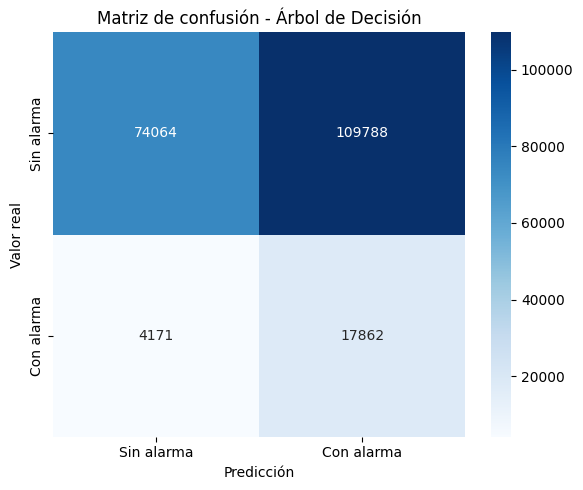

In [ ]:
# ============================================================
# 6.9 MATRIZ DE CONFUSIÓN
# ============================================================

matriz = confusion_matrix(y_test, predicciones[mejor_modelo])

plt.figure(figsize=(6,5))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sin alarma", "Con alarma"],
    yticklabels=["Sin alarma", "Con alarma"]
)

plt.title("Matriz de confusión - " + mejor_modelo)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.savefig("figura_matriz_confusion.png", dpi=300)
plt.show()

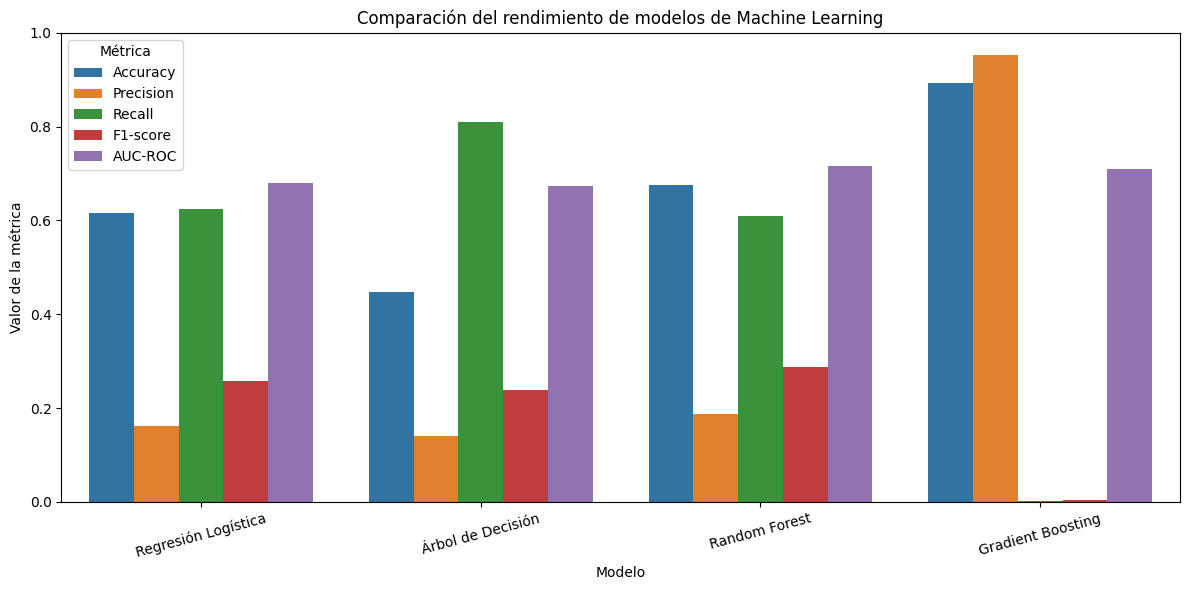

In [ ]:
# ============================================================
# 6.10 GRÁFICO COMPARATIVO DE MODELOS
# ============================================================

tabla_melt = tabla_resultados.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(12,6))
sns.barplot(data=tabla_melt, x="Modelo", y="Valor", hue="Métrica")

plt.title("Comparación del rendimiento de modelos de Machine Learning")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figura_comparacion_modelos.png", dpi=300)
plt.show()

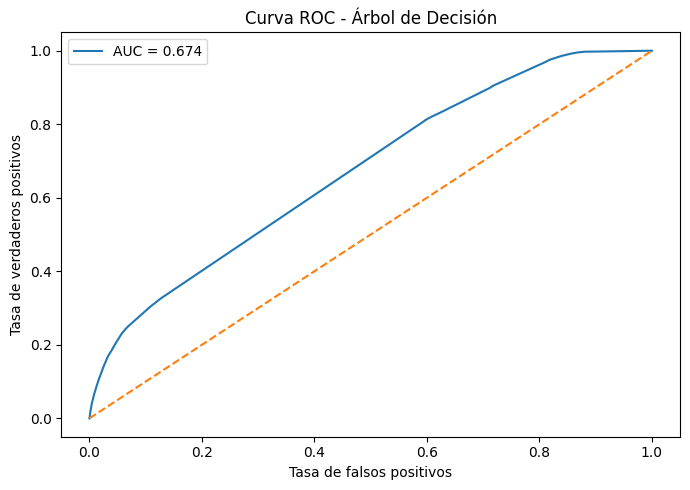

In [ ]:
# ============================================================
# 6.11 CURVA ROC DEL MEJOR MODELO
# ============================================================

if mejor_modelo in probabilidades:

    y_prob_mejor = probabilidades[mejor_modelo]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob_mejor)
    auc_mejor = roc_auc_score(y_test, y_prob_mejor)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_mejor:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.title("Curva ROC - " + mejor_modelo)
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figura_curva_roc.png", dpi=300)
    plt.show()

else:
    print("El mejor modelo no permite calcular probabilidades.")

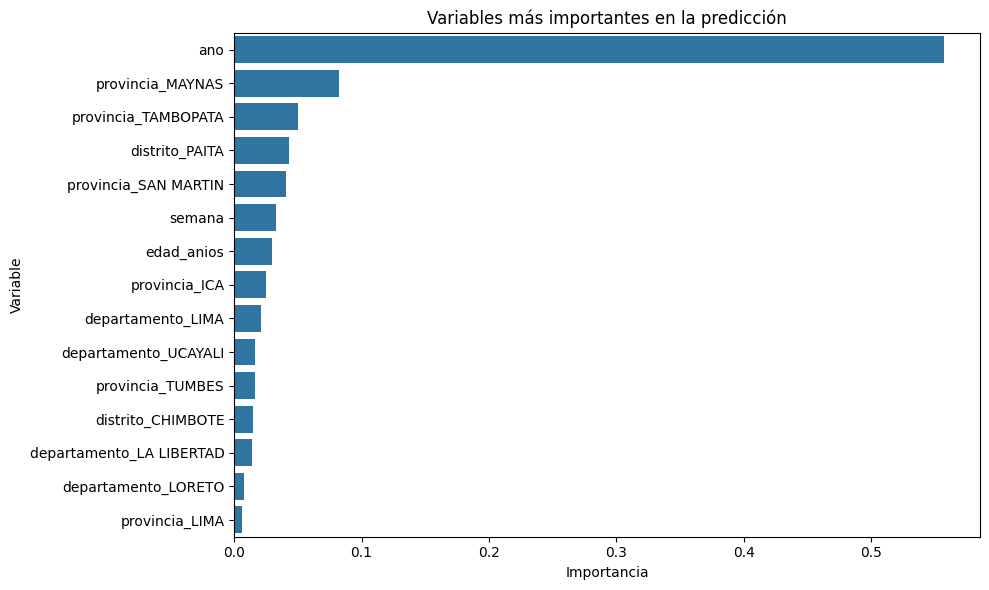

,Variable,Importancia
759,ano,0.557741
94,provincia_MAYNAS,0.082353
134,provincia_TAMBOPATA,0.050308
498,distrito_PAITA,0.043122
120,provincia_SAN MARTIN,0.040553
760,semana,0.032549
761,edad_anios,0.029990
78,provincia_ICA,0.024613
13,departamento_LIMA,0.020776
22,departamento_UCAYALI,0.016449


In [ ]:
# ============================================================
# 6.12 IMPORTANCIA DE VARIABLES
# Solo aplica bien para Árbol de Decisión o Random Forest
# ============================================================

if mejor_modelo in ["Árbol de Decisión", "Random Forest"]:

    pipeline_mejor = pipelines_entrenados[mejor_modelo]

    modelo_entrenado = pipeline_mejor.named_steps["modelo"]
    preprocesador_entrenado = pipeline_mejor.named_steps["preprocesador"]

    nombres_cat = preprocesador_entrenado.named_transformers_["cat"].get_feature_names_out(categoricas)
    nombres_variables = list(nombres_cat) + numericas

    importancias = modelo_entrenado.feature_importances_

    df_importancias = pd.DataFrame({
        "Variable": nombres_variables,
        "Importancia": importancias
    }).sort_values(by="Importancia", ascending=False).head(15)

    plt.figure(figsize=(10,6))
    sns.barplot(data=df_importancias, y="Variable", x="Importancia")

    plt.title("Variables más importantes en la predicción")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.savefig("figura_importancia_variables.png", dpi=300)
    plt.show()

    display(df_importancias)

else:
    print("La importancia de variables solo se graficó para Árbol de Decisión o Random Forest.")

In [ ]:
# ============================================================
# 6.13 TABLA FINAL PARA EL PAPER
# ============================================================

tabla_resultados_final = tabla_resultados.copy()

tabla_resultados_final["Accuracy"] = tabla_resultados_final["Accuracy"].round(3)
tabla_resultados_final["Precision"] = tabla_resultados_final["Precision"].round(3)
tabla_resultados_final["Recall"] = tabla_resultados_final["Recall"].round(3)
tabla_resultados_final["F1-score"] = tabla_resultados_final["F1-score"].round(3)
tabla_resultados_final["AUC-ROC"] = tabla_resultados_final["AUC-ROC"].round(3)

tabla_resultados_final

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Regresión Logística,0.616,0.163,0.625,0.258,0.680
1,Árbol de Decisión,0.446,0.140,0.811,0.239,0.674
2,Random Forest,0.676,0.188,0.610,0.287,0.717
3,Gradient Boosting,0.893,0.952,0.002,0.004,0.709


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Porcentaje de precisión:", accuracy * 100, "%")

Accuracy: 0.8931685164047891
Porcentaje de precisión: 89.31685164047892 %


In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)
print("Porcentaje de precision:", precision * 100, "%")

Precision: 0.9523809523809523
Porcentaje de precision: 95.23809523809523 %
